In [270]:
# import libraries and set defaults
import io
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


In [271]:
# reproducibility settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. UNDERSTAND YOUR DATA
This first section focuses on what the data actually is, what the important variables represent, and what the unit of observation is. 

The Welltory dataset is an open research dataset built around repeated HRV measurements, symptom tracking, and wearable context collected from participants in 2020.

The key question is: what is each row, what does each variable mean, and how are measurements related to participants?

In [272]:
# data repository config
GITHUB_API_URL = "https://api.github.com/repos/Welltory/hrv-covid19/git/trees/master?recursive=1"
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/"

In [273]:
# retreive the data repo file tree from github
response = requests.get(GITHUB_API_URL, timeout=30)
response.raise_for_status()

tree_data = response.json()

csv_paths = [
    item["path"]
    for item in tree_data["tree"]
    if item["type"] == "blob" and item["path"].lower().endswith(".csv")
]

print(f"Found {len(csv_paths)} CSV files in the repository.")
for path in csv_paths:
    print(path)

Found 9 CSV files in the repository.
data/blood_pressure.csv
data/heart_rate.csv
data/hrv_measurements.csv
data/participants.csv
data/scales_description.csv
data/sleep.csv
data/surveys.csv
data/wearables.csv
data/weather.csv


In [274]:
# download csv files into pandas dfs
datasets = {}
load_errors = {}

for path in csv_paths:
    url = GITHUB_RAW_BASE + path
    dataset_name = Path(path).stem.lower()

    try:
        df = pd.read_csv(url)
        datasets[dataset_name] = df
        print(f"{dataset_name:40s} {df.shape}")
    except Exception as exc:
        load_errors[path] = str(exc)
        print(f"Could not load {path}: {exc}")

blood_pressure                           (721, 8)
heart_rate                               (523783, 4)
hrv_measurements                         (3245, 22)
participants                             (185, 8)
scales_description                       (148, 4)
sleep                                    (425, 12)
surveys                                  (2259, 5)
wearables                                (3098, 18)
weather                                  (1717, 7)


# Dataset
The code below provides the dimensions and column names of every CSV that was successfully loaded. This helps identify which tables are appropriate for the analysis.

In [275]:
# get dataset names and dims for dataset
dataset_inventory = []

for name, df in datasets.items():
    dataset_inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    })

dataset_inventory = pd.DataFrame(dataset_inventory).sort_values("rows", ascending=False)
display(dataset_inventory)

,dataset,rows,columns,missing_cells,duplicate_rows
1,heart_rate,523783,4,0,0
2,hrv_measurements,3245,22,2823,0
7,wearables,3098,18,26887,0
6,surveys,2259,5,0,0
8,weather,1717,7,0,0
0,blood_pressure,721,8,1704,0
5,sleep,425,12,2873,0
3,participants,185,8,58,0
4,scales_description,148,4,0,0


In [276]:
# print column names for every loaded dataset
for name, df in datasets.items():
    print(f"\n{name}")
    print(list(df.columns))


blood_pressure
['user_code', 'measurement_datetime', 'diastolic', 'systolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']

heart_rate
['user_code', 'datetime', 'heart_rate', 'is_resting']

hrv_measurements
['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']

participants
['user_code', 'gender', 'age_range', 'city', 'country', 'height', 'weight', 'symptoms_onset']

scales_description
['Scale', 'Description', 'Value', 'Meaning']

sleep
['user_code', 'day', 'sleep_begin', 'sleep_end', 'sleep_duration', 'sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration', 'pulse_min', 'pulse_max', 'pulse_average']

surveys
['user_code', 'scale', 'created_at', 'value', 'text']

wearables
['user_code', 'day', 'resting_pulse', 'pulse_average'

# Primary dataset selection
I selected the HRV table as the main dataset because it is the table most directly connected to the heart-rate variability measurements that are central to this analysis.

In [277]:
# find table
hrv = datasets["hrv_measurements"].copy()

print("Primary HRV dataset: hrv_measurements")
print(f"Shape: {hrv.shape}")

Primary HRV dataset: hrv_measurements
Shape: (3245, 22)


In [278]:
# set columns
participant_col = "user_code"
measurement_col = "rr_code"
datetime_col = "measurement_datetime"

print("Participant column:", participant_col)
print("Measurement column:", measurement_col)
print("Datetime column:", datetime_col)

Participant column: user_code
Measurement column: rr_code
Datetime column: measurement_datetime


# Important features and unit of observation
In this dataset, each row is a single measurement, not necessarily a single participant. 

The exact variables vary across tables, but the most important fields include:
- heart rate in BPM
- RMSSD or other HRV summary metrics
- time and date information for the measurement
- participant or user identifiers for repeated measurements from the same person
- optional symptom or wearable-related context in other tables

The unit of observation is a measurement, and the unit of analysis may be a participant, a time period, or a specific measurement depending on the question we are asking.

In [279]:
numeric_columns = [
    "bpm",
    "meanrr",
    "mxdmn",
    "sdnn",
    "rmssd",
    "pnn50",
    "mode",
    "amo",
    "lf",
    "hf",
    "vlf",
    "lfhf",
    "total_power",
]

print("Physiological variables:")
print(numeric_columns)

Physiological variables:
['bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power']


# 2. Data context and data sampling
The Welltory COVID-19 and Wearables Open Data Research project was collected in 2020.
Participants tracked symptoms, HRV measurements, and information from connected devices.

The dataset is described as anonymized, but the repeated measurements still provide a useful longitudinal record of participant behavior and physiology.

The most important sampling issue is that this is not a one-row-per-person dataset. It contains repeated observations for the same users over time, so the total number of rows does not necessarily equal the number of participants. A single participant may contribute many HRV measurements, and each measurement is a separate observation in the dataset.

In [280]:
# get total measurements, unique participants, and unique measurement identifiers
print("Total measurements:", len(hrv))
print("Unique participants:", hrv[participant_col].nunique())
print("Unique measurement identifiers:", hrv[measurement_col].nunique())


Total measurements: 3245
Unique participants: 185
Unique measurement identifiers: 3245


In [281]:
# get measurements per participant
measurements_per_participant = hrv.groupby(participant_col).size()

print("Measurements per participant:")
display(measurements_per_participant.describe())

Measurements per participant:


count    185.000000
mean      17.540541
std       45.790517
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      405.000000
dtype: float64

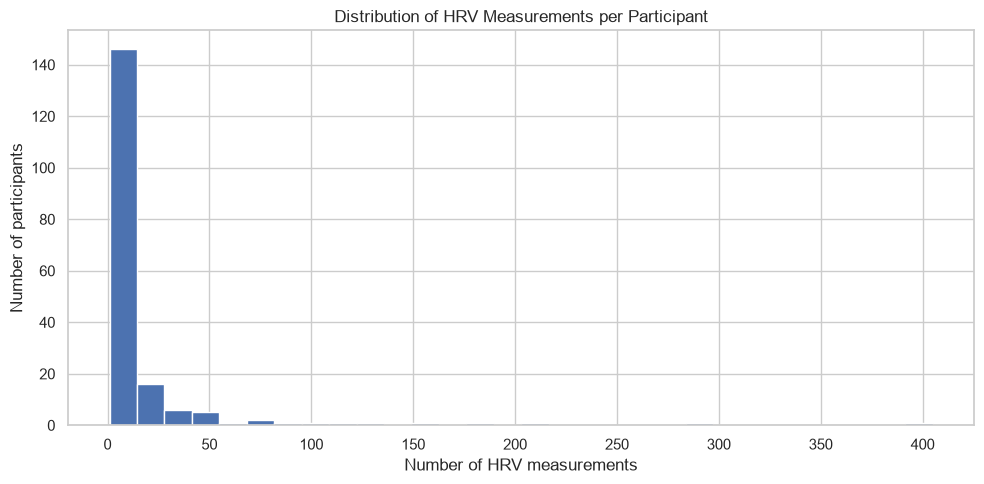

In [282]:
# create histogram
plt.figure(figsize=(10, 5))

plt.hist(measurements_per_participant, bins=30)

plt.xlabel("Number of HRV measurements")
plt.ylabel("Number of participants")
plt.title("Distribution of HRV Measurements per Participant")

plt.tight_layout()
plt.show()

# 3. Data structure, descriptive statistics, data quality, and variable relationships
This section I look at descriptive statistics, missing values, and the relationships between key HRV measurements. This helps me understand the data before making decisions about cleaning, handling outliers, and transforming variables. I also use this initial analysis to identify any data quality issues that could affect my results.

In [283]:
# rows and cols
print("Rows:", hrv.shape[0])
print("Columns:", hrv.shape[1])

Rows: 3245
Columns: 22


In [284]:
# head of the dataset
display(hrv.head())

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


In [285]:
# dataset info
hrv.info()

<class 'pandas.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   str    
 1   rr_code               3245 non-null   str    
 2   measurement_datetime  3245 non-null   str    
 3   time_of_day           3245 non-null   str    
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                  3245 non-n

In [286]:
# data quality summary
display(
    pd.DataFrame({
        "dtype": hrv.dtypes.astype(str),
        "non_null": hrv.notna().sum(),
        "missing": hrv.isna().sum(),
        "missing_percent": hrv.isna().mean() * 100,
        "unique": hrv.nunique(dropna=True)
    }).sort_values("missing_percent", ascending=False)
)

,dtype,non_null,missing,missing_percent,unique
how_sleep,float64,1466,1779,54.822804,5
tags,str,2201,1044,32.172573,1187
user_code,str,3245,0,0.000000,185
rr_code,str,3245,0,0.000000,3245
how_mood,int64,3245,0,0.000000,5
how_feel,int64,3245,0,0.000000,5
total_power,float64,3245,0,0.000000,2275
lfhf,float64,3245,0,0.000000,1982
vlf,float64,3245,0,0.000000,1283
hf,float64,3245,0,0.000000,1524


In [287]:
# descriptive stats for numerical values
numeric_cols = hrv.select_dtypes(include=np.number).columns.tolist()
display(hrv[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740
mxdmn,3245.0,0.184635,0.107456,0.030,0.110,0.160,0.220,0.790
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920
mode,3245.0,0.837465,0.144769,0.475,0.725,0.825,0.925,1.325
amo,3245.0,46.788290,16.418873,12.000,35.000,45.000,57.000,98.000
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000
hf,3245.0,1125.041294,2490.540413,4.000,158.000,380.000,993.000,33490.000


In [288]:
# descriptive stats for non-numerical values
categorical_cols = hrv.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

if categorical_cols:
    display(hrv[categorical_cols].describe().T)

/var/folders/pz/_2jpjwvj2pl4_vzwh68d8rw00000gn/T/ipykernel_5431/536629856.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = hrv.select_dtypes(


,count,unique,top,freq
user_code,3245,185,a62c11c164,405
rr_code,3245,3245,10489a6aea,1
measurement_datetime,3245,3241,2020-04-22 09:13:10,2
time_of_day,3245,4,morning,1467
tags,2201,1187,COVID-19,208
rr_data,3245,3245,"819,1008,831,847,785,778,866,839,801,793,846,8...",1


In [289]:
# data profiling summary
profile = pd.DataFrame(index=hrv.columns)

profile["dtype"] = hrv.dtypes.astype(str)
profile["rows"] = len(hrv)
profile["non_null"] = hrv.notna().sum()
profile["missing"] = hrv.isna().sum()
profile["missing_percent"] = (hrv.isna().mean() * 100).round(2)
profile["unique_values"] = hrv.nunique(dropna=True)
profile["unique_percent"] = (
    hrv.nunique(dropna=True) / len(hrv) * 100
).round(2)

display(profile.sort_values("missing_percent", ascending=False))

,dtype,rows,non_null,missing,missing_percent,unique_values,unique_percent
how_sleep,float64,3245,1466,1779,54.82,5,0.15
tags,str,3245,2201,1044,32.17,1187,36.58
user_code,str,3245,3245,0,0.00,185,5.70
rr_code,str,3245,3245,0,0.00,3245,100.00
how_mood,int64,3245,3245,0,0.00,5,0.15
how_feel,int64,3245,3245,0,0.00,5,0.15
total_power,float64,3245,3245,0,0.00,2275,70.11
lfhf,float64,3245,3245,0,0.00,1982,61.08
vlf,float64,3245,3245,0,0.00,1283,39.54
hf,float64,3245,3245,0,0.00,1524,46.96


# NOTE 
Missing values are not automatically errors

In [290]:
# correlation matrix
correlation_columns = hrv.select_dtypes(include=np.number).columns.tolist()
correlation_columns = [
    col for col in correlation_columns
    if hrv[col].notna().mean() >= 0.50
]

if len(correlation_columns) >= 2:
    correlation_matrix = hrv[correlation_columns].corr()

    print("Correlation matrix available for:", correlation_columns)

    corr_pairs = (
        correlation_matrix.where(
            np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
        )
        .stack()
        .reset_index()
    )

    corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
    corr_pairs["absolute_correlation"] = corr_pairs["correlation"].abs()

    display(
        corr_pairs
        .sort_values("absolute_correlation", ascending=False)
        .head(15)
    )

Correlation matrix available for: ['bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood']


,variable_1,variable_2,correlation,absolute_correlation
21,meanrr,mode,0.979400,0.979400
1,bpm,meanrr,-0.977724,0.977724
6,bpm,mode,-0.956984,0.956984
33,mxdmn,sdnn,0.954639,0.954639
147,hf,total_power,0.911203,0.911203
49,sdnn,rmssd,0.909046,0.909046
57,sdnn,total_power,0.879030,0.879030
69,rmssd,hf,0.857374,0.857374
42,mxdmn,total_power,0.848769,0.848769
34,mxdmn,rmssd,0.846259,0.846259


The correlation analysis shows several strong relationships between the HRV variables. For example, meanrr and mode have a correlation of 0.979, while bpm and meanrr have a correlation of -0.978. Other variables, including sdnn, rmssd, pnn50, and total_power, also show relatively strong positive correlations with one another.

These correlations show that several HRV measurements tend to change together, but they do not mean that one variable causes another. Some of these strong relationships may occur because the variables are mathematically related or are calculated from similar underlying physiological measurements. I therefore use the correlations to understand relationships within the dataset rather than to make causal conclusions.

# 4. Exploratory visualizations

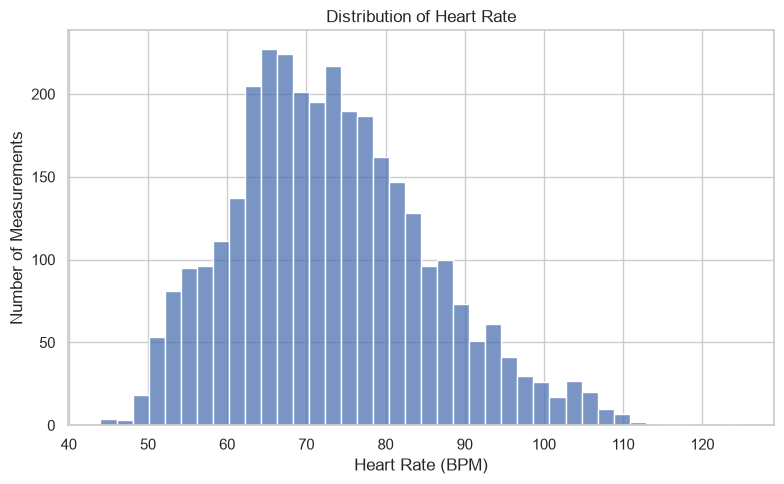

In [291]:
# heart rate distribution
heart_rate_col = "bpm" if "bpm" in hrv.columns else None

plt.figure(figsize=(8, 5))
sns.histplot(hrv[heart_rate_col].dropna(), bins=40)
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Number of Measurements")
plt.title("Distribution of Heart Rate")
plt.tight_layout()
plt.show()

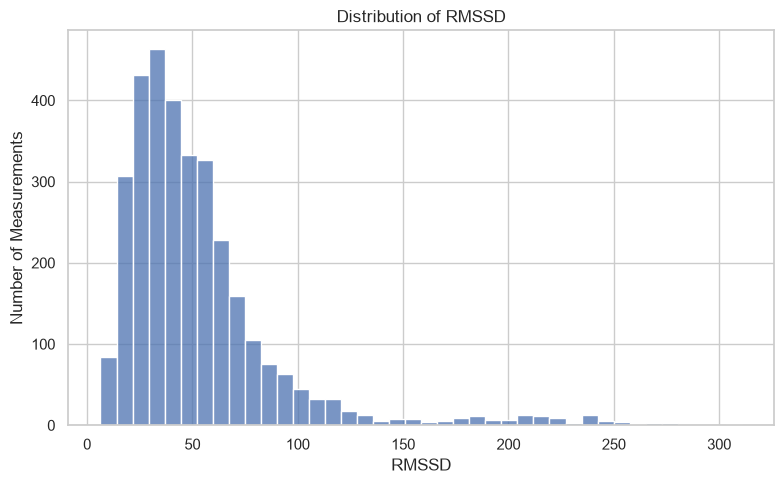

In [292]:
# rmssd distribution
rmssd_col = "rmssd" if "rmssd" in hrv.columns else None

plt.figure(figsize=(8, 5))
sns.histplot(hrv[rmssd_col].dropna(), bins=40)
plt.xlabel("RMSSD")
plt.ylabel("Number of Measurements")
plt.title("Distribution of RMSSD")
plt.tight_layout()
plt.show()

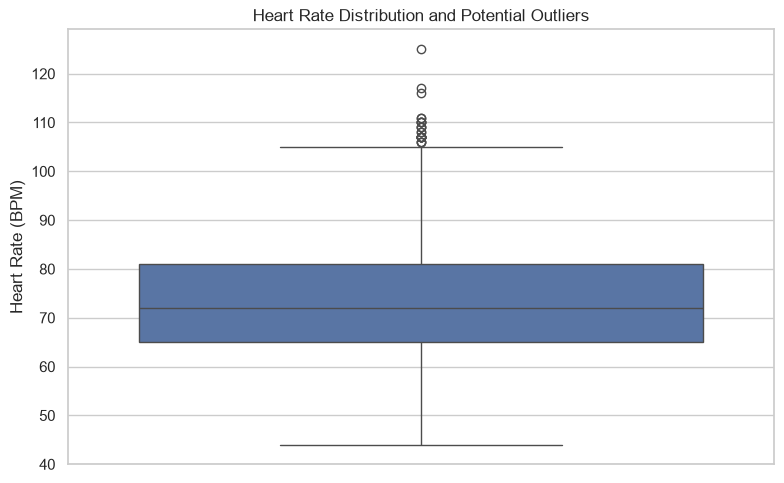

In [293]:
# heartrate boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(y=hrv[heart_rate_col])
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Distribution and Potential Outliers")
plt.tight_layout()
plt.show()

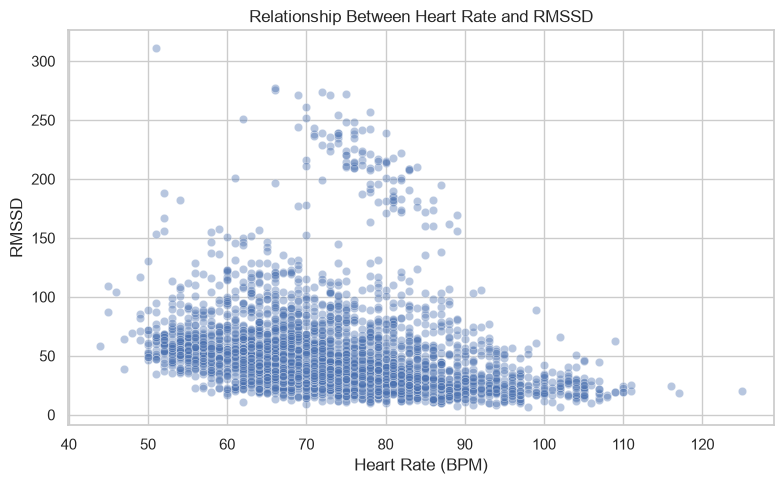

In [294]:
# heart rate versus rmssd
plot_data = hrv[[heart_rate_col, rmssd_col]].dropna()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_data,
    x=heart_rate_col,
    y=rmssd_col,
    alpha=0.4
)
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("RMSSD")
plt.title("Relationship Between Heart Rate and RMSSD")
plt.tight_layout()
plt.show()

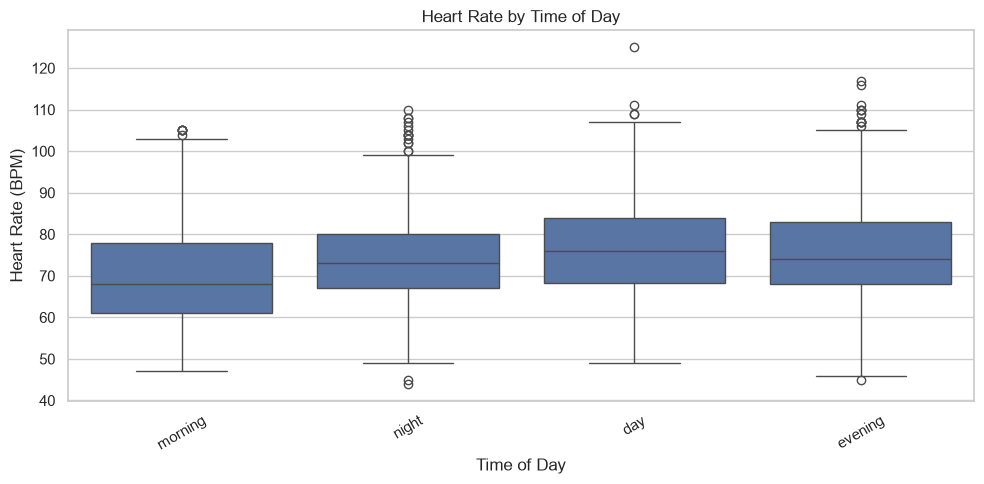

In [295]:
# time of day relationship
time_of_day_col = "time_of_day" if "time_of_day" in hrv.columns else None

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=hrv,
    x=time_of_day_col,
    y=heart_rate_col
)
plt.xlabel("Time of Day")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate by Time of Day")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

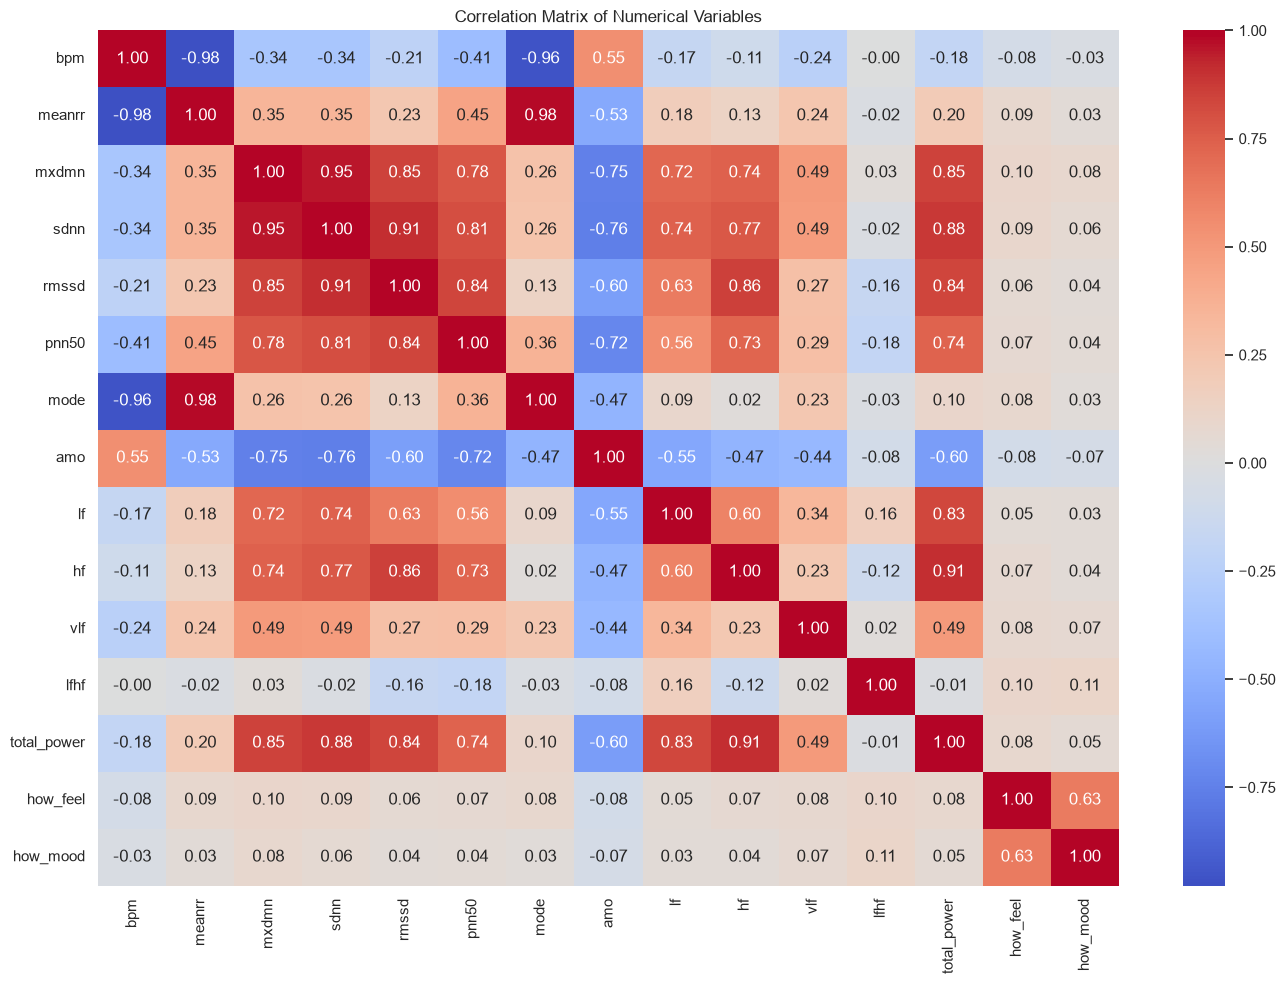

In [296]:
# correlation heatmap
if len(correlation_columns) >= 2:
    correlation_matrix = hrv[correlation_columns].corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )
    plt.title("Correlation Matrix of Numerical Variables")
    plt.tight_layout()
    plt.show()

# 5a) Handling missing values
I found that some variables in the dataset contain missing values, so I use a selective approach rather than filling every missing value automatically. For numerical variables with less than 30% missing data, I use the median to fill the missing values because it is less affected by extreme values and skewed distributions. For variables with more than 30% missing data, I leave the values missing rather than adding a large amount of estimated data that could distort the results.

For categorical variables with less than 50% missing data, I replace the missing values with "Unknown". This allows me to keep those observations while making it clear that the original value was not available.

In [297]:
# working copy of the dataset for cleaning and transformation
hrv_clean = hrv.copy()

In [298]:
# mean imputation for missing values in numerical columns where less than 30% of the data is missing
imputation_columns = [
    col
    for col in resolved_numeric_candidates
    if hrv_clean[col].isna().mean() < 0.30
]

for col in imputation_columns:
    hrv_clean[col] = hrv_clean[col].fillna(hrv_clean[col].median())

print("Variables median-imputed:")
print(imputation_columns)

Variables median-imputed:
['bpm', 'meanrr', 'sdnn', 'rmssd', 'pnn50', 'lf', 'hf', 'total_power']


In [299]:
# fill missing categorical values
categorical_cleaning_columns = [
    col for col in hrv_clean.select_dtypes(
        include=["object", "category", "bool"]
    ).columns
    if hrv_clean[col].isna().mean() < 0.50
]

for col in categorical_cleaning_columns:
    hrv_clean[col] = hrv_clean[col].fillna("Unknown")

print("Categorical variables handled:")
print(categorical_cleaning_columns)

Categorical variables handled:
['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'tags', 'rr_data']


/var/folders/pz/_2jpjwvj2pl4_vzwh68d8rw00000gn/T/ipykernel_5431/2675524141.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in hrv_clean.select_dtypes(


In [300]:
# missing value summary after cleaning
missing_after = hrv_clean.isna().sum().to_frame("missing_count")
missing_after["missing_percent"] = (missing_after["missing_count"] / len(hrv_clean) * 100).round(2)

display(missing_after.sort_values("missing_percent", ascending=False).head(20))

,missing_count,missing_percent
how_sleep,1779,54.82
user_code,0,0.00
rr_code,0,0.00
tags,0,0.00
how_mood,0,0.00
how_feel,0,0.00
total_power,0,0.00
lfhf,0,0.00
vlf,0,0.00
hf,0,0.00


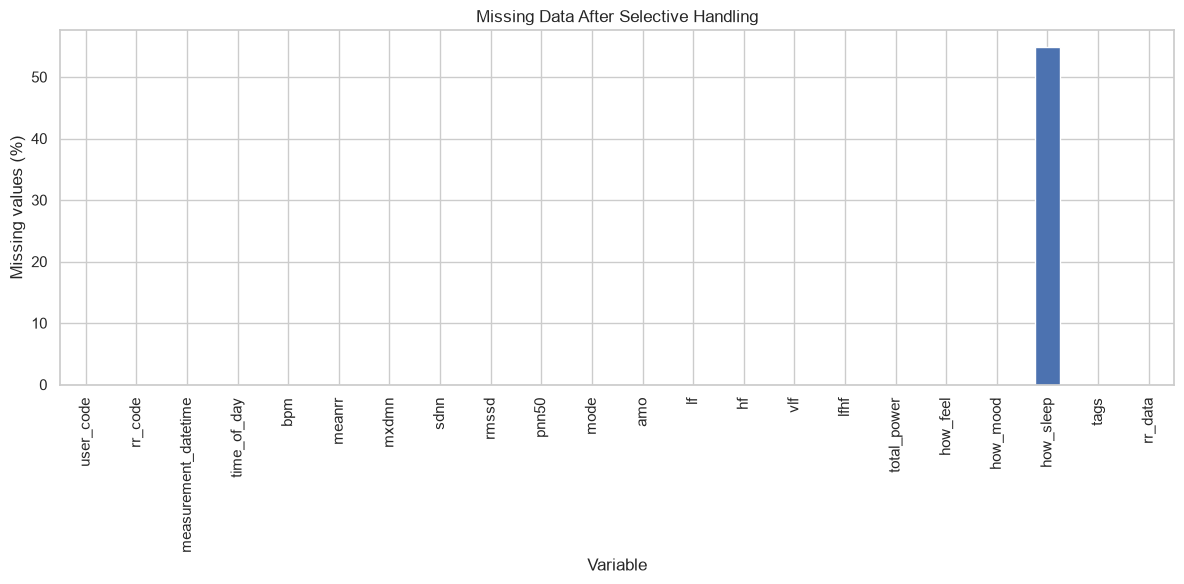

In [301]:
plt.figure(figsize=(12, 6))
missing_after["missing_percent"].plot(kind="bar")
plt.xlabel("Variable")
plt.ylabel("Missing values (%)")
plt.title("Missing Data After Selective Handling")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 5b) Removing Duplicates

I checked the dataset for duplicate records because duplicate rows could cause the same measurement to be counted more than once. I removed exact duplicate rows from the dataset. However, I did not treat repeated participant IDs as duplicates because participants can have multiple HRV measurements over time. Keeping these repeated measurements is important because they represent separate observations from the same participant.

In [302]:
# get duplicate count
exact_duplicate_count = hrv_clean.duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_count)
print("Percentage of rows duplicated:", round(
    exact_duplicate_count / len(hrv_clean) * 100, 2
), "%")

Exact duplicate rows: 0
Percentage of rows duplicated: 0.0 %


In [303]:
# get rid of dupes
if exact_duplicate_count > 0:
    display(hrv_clean[hrv_clean.duplicated(keep=False)].head(20))

In [304]:
# remove exact dupes
hrv_clean = hrv_clean.drop_duplicates().reset_index(drop=True)

print("Shape after exact duplicate removal:", hrv_clean.shape)

Shape after exact duplicate removal: (3245, 22)


# 5c) Handling Outliers

I identify potential outliers using the interquartile range (IQR) method. This flags values that fall substantially below or above the middle 50% of the data. However, I do not assume that every statistical outlier is an error. Since this is physiological data, unusual measurements can represent legitimate differences between participants or measurements. I therefore focus on identifying values that are clearly invalid, such as negative values for physiological measurements that cannot be negative, rather than automatically removing every statistical outlier.

In [305]:
def iqr_outlier_summary(df, columns):
    results = []

    for col in columns:
        series = df[col].dropna()

        if len(series) == 0:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (df[col] < lower) | (df[col] > upper)

        results.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(mask.sum()),
            "outlier_percent": round(mask.mean() * 100, 2)
        })

    return pd.DataFrame(results)

In [306]:
outlier_summary = iqr_outlier_summary(
    hrv_clean,
    resolved_numeric_candidates
)

display(
    outlier_summary.sort_values(
        "outlier_percent",
        ascending=False
    )
)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
6,hf,158.000,993.000,835.000,-1094.5000,2245.5000,334,10.29
5,lf,151.000,1059.000,908.000,-1211.0000,2421.0000,291,8.97
7,total_power,620.000,2906.000,2286.000,-2809.0000,6335.0000,266,8.20
3,rmssd,28.985,62.485,33.500,-21.2650,112.7350,195,6.01
2,sdnn,32.585,64.406,31.821,-15.1465,112.1375,149,4.59
4,pnn50,6.060,29.290,23.230,-28.7850,64.1350,127,3.91
0,bpm,65.000,81.000,16.000,41.0000,105.0000,25,0.77
1,meanrr,742.490,925.933,183.443,467.3255,1201.0975,12,0.37


In [307]:
invalid_rows = pd.Series(False, index=hrv_clean.index)

for col in resolved_numeric_candidates:
    lower_is_invalid = any(
        term in col.lower()
        for term in [
            "bpm",
            "heart",
            "meanrr",
            "rr",
            "sdnn",
            "rmssd",
            "power",
            "lf",
            "hf"
        ]
    )

    if lower_is_invalid:
        invalid_rows |= hrv_clean[col] < 0

print("Rows containing negative values in variables where negative values are invalid:",
      invalid_rows.sum())

Rows containing negative values in variables where negative values are invalid: 0


In [308]:
hrv_clean = hrv_clean.loc[~invalid_rows].reset_index(drop=True)

print("Shape after invalid-value removal:", hrv_clean.shape)

Shape after invalid-value removal: (3245, 22)


# 6a) Date and Time Conversion

I convert the measurement_datetime column to a pandas datetime format so I can work with the timing of each HRV measurement consistently. This allows me to create additional time-based features, such as the date, hour, day of the week, and month, which can be used to identify patterns in when measurements were taken.

In [309]:
hrv_clean[datetime_col] = pd.to_datetime(
    hrv_clean[datetime_col],
    errors="coerce"
)

print("Invalid/unparseable timestamps:", hrv_clean[datetime_col].isna().sum())
print("Earliest measurement:", hrv_clean[datetime_col].min())
print("Latest measurement:", hrv_clean[datetime_col].max())


hrv_clean["measurement_date"] = hrv_clean[datetime_col].dt.date
hrv_clean["measurement_hour"] = hrv_clean[datetime_col].dt.hour
hrv_clean["day_of_week"] = hrv_clean[datetime_col].dt.day_name()
hrv_clean["month"] = hrv_clean[datetime_col].dt.month

Invalid/unparseable timestamps: 0
Earliest measurement: 2019-12-31 06:08:29
Latest measurement: 2020-06-19 11:40:13


# 6b) Skewness and Log Transformation

I check the distribution of RMSSD to see whether it is heavily skewed. If the values are non-negative, I apply a log1p() transformation to reduce right skewness and make the distribution easier to analyze. I compare the skewness before and after the transformation to see whether it improves the distribution.

In [310]:
transformation_summary = []

for col in resolved_numeric_candidates:
    if col in hrv_clean.columns and pd.api.types.is_numeric_dtype(hrv_clean[col]):
        transformation_summary.append({
            "variable": col,
            "skewness_before": hrv_clean[col].skew()
        })

transformation_summary = pd.DataFrame(transformation_summary)
display(transformation_summary.sort_values("skewness_before", ascending=False))


,variable,skewness_before
6,hf,5.339414
5,lf,3.802072
7,total_power,3.791925
3,rmssd,2.658394
2,sdnn,1.719168
4,pnn50,1.405382
0,bpm,0.482403
1,meanrr,0.334116


In [311]:
if (hrv_clean[rmssd_col] >= 0).all():
    hrv_clean["log_rmssd"] = np.log1p(hrv_clean[rmssd_col])

In [312]:
print("Original RMSSD skewness:", hrv_clean[rmssd_col].skew())
print("Log RMSSD skewness:", hrv_clean["log_rmssd"].skew())

Original RMSSD skewness: 2.6583944569280895
Log RMSSD skewness: 0.3472785686541894


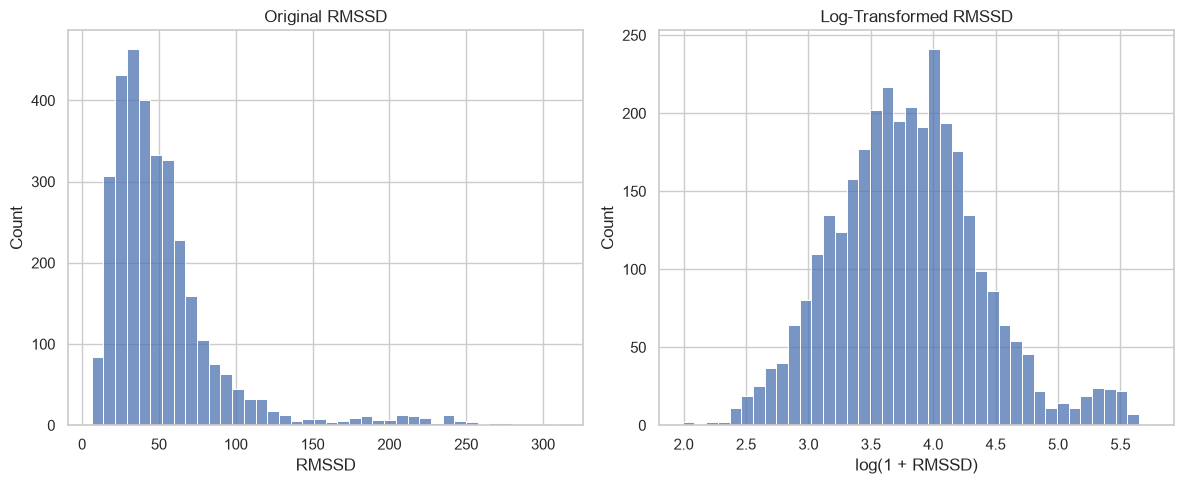

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(hrv_clean[rmssd_col].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Original RMSSD")
axes[0].set_xlabel("RMSSD")

sns.histplot(hrv_clean["log_rmssd"].dropna(), bins=40, ax=axes[1])
axes[1].set_title("Log-Transformed RMSSD")
axes[1].set_xlabel("log(1 + RMSSD)")

plt.tight_layout()
plt.show()

# 7. Feature Engineering

I create a new feature to capture how each participant's heart rate compares with their own typical heart rate. This accounts for differences between people, since the same heart rate may be relatively high for one participant but normal for another. The new feature is calculated by subtracting each participant's average heart rate from their individual measurement.

In [314]:
participant_mean_hr = hrv_clean.groupby(
    participant_col
)[heart_rate_col].transform("mean")

hrv_clean["bpm_deviation_from_user_mean"] = (
    hrv_clean[heart_rate_col] - participant_mean_hr
)

display(
    hrv_clean[
        [
            participant_col,
            heart_rate_col,
            "bpm_deviation_from_user_mean"
        ]
    ].head(10)
)

,user_code,bpm,bpm_deviation_from_user_mean
0,007b8190cf,75,2.500000
1,007b8190cf,70,-2.500000
2,013f6d3e5b,83,4.000000
3,013f6d3e5b,75,-4.000000
4,01bad5a519,78,0.255556
5,01bad5a519,69,-8.744444
6,01bad5a519,73,-4.744444
7,01bad5a519,73,-4.744444
8,01bad5a519,84,6.255556
9,01bad5a519,68,-9.744444


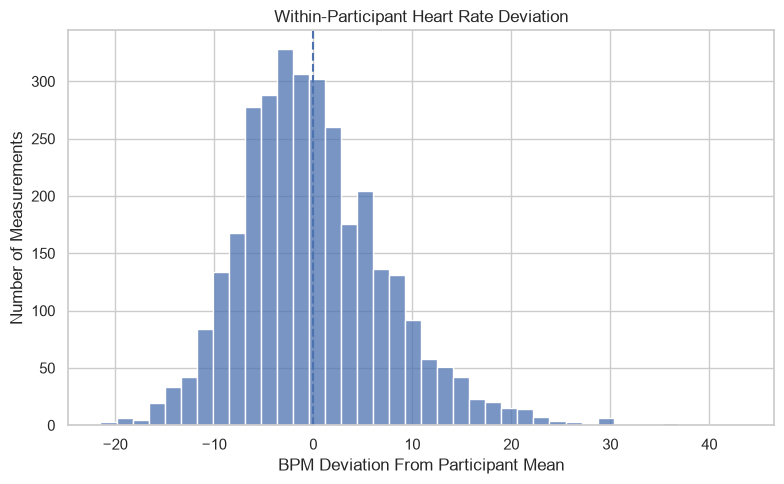

In [315]:
plt.figure(figsize=(8, 5))
sns.histplot(
    hrv_clean["bpm_deviation_from_user_mean"].dropna(),
    bins=40
)
plt.axvline(0, linestyle="--")
plt.xlabel("BPM Deviation From Participant Mean")
plt.ylabel("Number of Measurements")
plt.title("Within-Participant Heart Rate Deviation")
plt.tight_layout()
plt.show()

This feature is useful because two users with the same absolute heart rate may not be in the same relative physiological state. A positive deviation means the current measurement is above that participant's usual average, while a negative deviation means it is below that participant's average. The feature is descriptive rather than diagnostic and does not establish disease or causality.

In [316]:
participant_summary = (
    hrv_clean
    .groupby(participant_col)
    .agg(
        measurements=(participant_col, "size"),
        mean_heart_rate=(
            heart_rate_col,
            "mean"
        ),
        mean_rmssd=(
            rmssd_col,
            "mean"
        )
    )
    .reset_index()
)

display(participant_summary.head())

,user_code,measurements,mean_heart_rate,mean_rmssd
0,007b8190cf,2,72.500000,43.598000
1,013f6d3e5b,2,79.000000,68.013000
2,01bad5a519,90,77.744444,25.537978
3,0210b20eea,5,78.400000,29.732800
4,024719e7da,3,72.000000,74.369333


# 8. Data Quality Assessment, Lineage, and Provenance

In this section, I bring together the main data quality checks I performed throughout the analysis. I assess data profiling, completeness, accuracy, consistency, and integrity, and I also document the lineage and provenance of the dataset. I explain what I was able to verify directly, what could not be fully verified without an external reference source, and how the final cleaned dataset was created from the original source files.

# Data Profiling

I profiled the dataset before making any cleaning decisions to understand its overall structure and quality. I examined the number of rows and columns, data types, missing values, unique values, and descriptive statistics for the main variables. This gave me an initial understanding of the data and helped me identify issues that needed to be addressed during the cleaning process.

In [317]:
profile = pd.DataFrame(index=hrv.columns)
profile["dtype"] = hrv.dtypes.astype(str)
profile["rows"] = len(hrv)
profile["non_null"] = hrv.notna().sum()
profile["missing"] = hrv.isna().sum()
profile["missing_percent"] = (hrv.isna().mean() * 100).round(2)
profile["unique_values"] = hrv.nunique(dropna=True)
profile["unique_percent"] = (
    hrv.nunique(dropna=True) / len(hrv) * 100
).round(2)

display(profile.sort_values("missing_percent", ascending=False).head(20))

,dtype,rows,non_null,missing,missing_percent,unique_values,unique_percent
how_sleep,float64,3245,1466,1779,54.82,5,0.15
tags,str,3245,2201,1044,32.17,1187,36.58
user_code,str,3245,3245,0,0.00,185,5.70
rr_code,str,3245,3245,0,0.00,3245,100.00
how_mood,int64,3245,3245,0,0.00,5,0.15
how_feel,int64,3245,3245,0,0.00,5,0.15
total_power,float64,3245,3245,0,0.00,2275,70.11
lfhf,float64,3245,3245,0,0.00,1982,61.08
vlf,float64,3245,3245,0,0.00,1283,39.54
hf,float64,3245,3245,0,0.00,1524,46.96


# Data Completeness

I assessed data completeness by checking the number and percentage of missing values for each variable. Missing values are expected in a real-world wearable dataset because not every measurement is necessarily recorded for every participant. I therefore handled missing values selectively based on the amount of missing data rather than assuming that every missing value was an error.

In [318]:
missing_summary = (
    hrv.isna().sum().to_frame("missing_count")
)
missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(hrv) * 100).round(2)
display(missing_summary.sort_values("missing_percent", ascending=False).head(20))


,missing_count,missing_percent
how_sleep,1779,54.82
tags,1044,32.17
user_code,0,0.00
rr_code,0,0.00
how_mood,0,0.00
how_feel,0,0.00
total_power,0,0.00
lfhf,0,0.00
vlf,0,0.00
hf,0,0.00


# Data Accuracy

I assessed accuracy by checking whether the values were reasonable for the type of data being collected. Since I do not have an external gold-standard source to compare the measurements against, I cannot fully verify the accuracy of the dataset. Instead, I used range checks, domain plausibility checks, and invalid-value detection to identify measurements that are clearly incorrect or impossible. These checks can identify obvious data quality issues, but they cannot confirm that every value in the dataset is accurate.

In [319]:
percentage_columns = ["pnn50"]

for col in percentage_columns:
    invalid = ((hrv_clean[col] < 0) | (hrv_clean[col] > 100)).sum()
    print(f"{col}: {invalid} values outside 0-100")

if any(term in col.lower() for term in ["bpm", "heart", "meanrr", "rr", "sdnn", "rmssd", "power", "lf", "hf"]):
        negative_count = (hrv_clean[col] < 0).sum()
        print(f"{col}: {negative_count} negative values")

pnn50: 0 values outside 0-100


# Data Consistency

I checked the dataset for inconsistent data types, values outside expected ranges, and violations of basic domain rules. For example, I checked for negative physiological measurements and percentage variables outside the 0–100 range. These checks helped me identify values that were inconsistent with reasonable expectations for the data. However, I did not assume that every unusual value was an error, since some unusual physiological measurements may still be legitimate.

In [320]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(hrv_clean[col].value_counts(dropna=False).head(20))


--- user_code ---


user_code
a62c11c164    405
295ed96279    290
c174f32d88    205
a1c2e6b2eb    183
fcf3ea75b0    157
6be5033971    129
fde84801d8    109
f9edcb7056    101
01bad5a519     90
8011967ef0     78
aa036185e3     76
4c2702c3e1     65
3769e88689     54
1ce1d77659     53
e8240b51a2     51
1942df1c47     50
71980b2daf     48
276ab22485     41
425969dc69     41
3acfbb328e     40
Name: count, dtype: int64


--- rr_code ---


rr_code
10489a6aea    1
9610d4d4dc    1
f3de056155    1
b04489e32f    1
ac52c706c6    1
7c39e19d73    1
2ccb710069    1
d1cb7d3325    1
e146d669b6    1
2c07fb6bb4    1
a74f3091e4    1
53c620b404    1
3f09504167    1
0a58316238    1
c4e6cf97de    1
661bf9d967    1
ad20b9daf1    1
bb187cd20b    1
a76110ae11    1
fbe58a3f58    1
Name: count, dtype: int64


--- measurement_datetime ---


...

time_of_day
morning    1467
day         806
evening     701
night       271
Name: count, dtype: int64


--- tags ---


tags
Unknown                                 1044
COVID-19                                 208
Night                                     89
Morning                                   87
Day                                       78
After; Sleep; Morning                     74
Evening                                   54
Illness                                   30
After; Sleep                              24
After; Sleep; A lot; Morning              16
After; COVID-19                           15
Relaxing                                  12
Tired                                     12
COVID-19; Night                           12
COVID-19; Morning                         12
Tired; Night                              11
After; Sleep; After; Period; Morning      10
Before; Sleep                              9
After; COVID-19; A lot                     9
I am great!                                8
Name: count, dtype: int64


--- rr_data ---


rr_data
819,1008,831,847,785,778,866,839,801,793,846,856,800,791,816,847,822,790,783,800,811,754,767,813,823,793,782,830,852,801,761,660,837,1027,766,785,861,807,749,745,745,769,776,771,782,753,756,783,773,795,757,767,790,780,783,811,805,819,786,776,783,782,739,725,728,742,763,784,754,756,764,789,819,838,793,789,806,810,775,770,798,829,841,839,792,798,796,800,774,799,801,801,767,802,828,793,766,770,786,782    1
888,775,811,883,890,894,894,899,893,889,890,832,848,873,902,870,880,826,880,890,903,877,837,783,812,826,838,836,847,818,868,856,867,872,878,867,954,885,890,854,853,867,850,881,890,874,890,837,826,831,852,830,836,855,843,839,812,796,779,824,890,900,821,806,886,826,840,875,902,916,926,869,884,854,843,861,880,890,822,801,820,835,849,869,855,855,834,836,896,867,882,878,851,847,861,876,862,853,824,818      1
694,832,642,801,751,716,737,742,773,760,701,732,773,780,765,733,705,775,786,783,712,653,655,644,656,606,1047,830,792,711,726,756,766,754,705,718,715,764,737,718,708,745,769,776,7

# Data Integrity

I assessed data integrity by checking whether records could be reliably linked across the available datasets. I used the user_code identifier to compare participants across tables and reviewed rr_code to make sure measurement identifiers were not being treated as participant identifiers. This is important because the HRV dataset contains multiple measurements from the same participant rather than having one row per person.

In [321]:
participant_columns_by_dataset = {
    name: "user_code" if "user_code" in df.columns else None
    for name, df in datasets.items()
}

display(
    pd.DataFrame.from_dict(
        participant_columns_by_dataset,
        orient="index",
        columns=["participant_column"]
    )
)

,participant_column
blood_pressure,user_code
heart_rate,user_code
hrv_measurements,user_code
participants,user_code
scales_description,NaN
sleep,user_code
surveys,user_code
wearables,user_code
weather,user_code


In [322]:
hrv_participants = set(hrv_clean[participant_col].dropna().unique())

integrity_results = []

for name, df in datasets.items():
    other_col = participant_columns_by_dataset.get(name)

    if other_col is None:
        continue

    other_participants = set(df[other_col].dropna().unique())

    integrity_results.append({
        "dataset": name,
        "participant_column": other_col,
        "unique_participants": len(other_participants),
        "HRV_participants_found_in_dataset": len(
            hrv_participants.intersection(other_participants)
        ),
        "HRV_participants_not_found": len(
            hrv_participants - other_participants
        )
    })

display(pd.DataFrame(integrity_results))

,dataset,participant_column,unique_participants,HRV_participants_found_in_dataset,HRV_participants_not_found
0,blood_pressure,user_code,28,28,157
1,heart_rate,user_code,79,79,106
2,hrv_measurements,user_code,185,185,0
3,participants,user_code,185,185,0
4,sleep,user_code,10,10,175
5,surveys,user_code,111,111,74
6,wearables,user_code,79,79,106
7,weather,user_code,104,104,81


Data Lineage and Provenance

Welltory GitHub repository
       ->
GitHub repository tree / raw CSV files
       ->
pandas DataFrames
       ->
profiling and quality assessment
       ->
cleaning and transformation
       ->
feature engineering
       ->
exploratory analysis and visualization

In [323]:
# final summary to document the cleaning process.
final_quality_summary = pd.DataFrame({
    "metric": [
        "Original rows",
        "Final rows",
        "Rows removed",
        "Original columns",
        "Final columns",
        "Original missing cells",
        "Final missing cells",
        "Original exact duplicates",
        "Final exact duplicates"
    ],
    "value": [
        len(hrv),
        len(hrv_clean),
        len(hrv) - len(hrv_clean),
        len(hrv.columns),
        len(hrv_clean.columns),
        int(hrv.isna().sum().sum()),
        int(hrv_clean.isna().sum().sum()),
        int(hrv.duplicated().sum()),
        int(hrv_clean.duplicated().sum())
    ]
})

display(final_quality_summary)

,metric,value
0,Original rows,3245
1,Final rows,3245
2,Rows removed,0
3,Original columns,22
4,Final columns,28
5,Original missing cells,2823
6,Final missing cells,1779
7,Original exact duplicates,0
8,Final exact duplicates,0


In [324]:
display(hrv_clean.head())

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data,measurement_date,measurement_hour,day_of_week,month,log_rmssd,bpm_deviation_from_user_mean
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8...",2020-04-21,21,Tuesday,4,4.010492,2.500000
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,Unknown,"888,775,811,883,890,894,894,899,893,889,890,83...",2020-04-26,11,Sunday,4,3.527007,-2.500000
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73...",2020-05-15,4,Friday,5,4.204499,4.000000
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,Unknown,"821,817,771,805,833,788,747,724,792,825,775,75...",2020-05-19,3,Tuesday,5,4.263229,-4.000000
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,Unknown,"741,740,734,737,740,731,751,747,745,728,747,76...",2019-12-31,9,Tuesday,12,3.099912,0.255556


# Conclusions

Through my exploratory analysis, I found that the Welltory HRV dataset contains repeated measurements, meaning the unit of observation is an individual HRV measurement rather than a single participant. This structure allows me to examine measurements across participants and over time, but it also requires me to account for issues such as missing values, duplicate records, and unusual measurements.

My data cleaning process was selective. I removed exact duplicate rows, handled missing values based on the amount of missing data, and removed clearly invalid negative physiological measurements. I did not automatically remove statistical outliers because an unusual physiological measurement is not necessarily an error.

I also used data transformation and feature engineering to make the data easier to analyze. The log transformation of RMSSD was used to reduce its skewness, while the within-person heart-rate deviation feature provides context by comparing each measurement with the participant's typical heart rate.

Overall, this analysis provided an exploratory assessment of the dataset's structure, relationships, and data quality. The results help describe patterns and identify potential data-quality issues, but they do not establish causal relationships or determine medical significance.